In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [65]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'pacage(in LPA)')

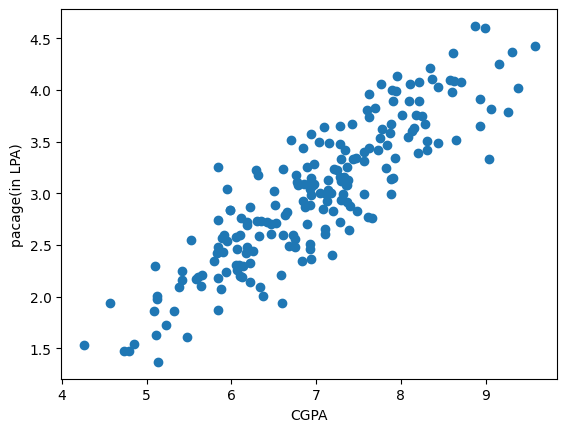

In [66]:
plt.scatter(x = df['cgpa'] , y=df['package'])
plt.xlabel('CGPA')
plt.ylabel('pacage(in LPA)')

In [67]:
X = df.iloc[: , 0:1]
y = df.iloc[: , -1]

In [68]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=True)

In [69]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.58]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.086
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [70]:
X_test

,cgpa
58,6.92
40,9.38
34,7.34
102,5.13
184,7.88
198,7.63
95,6.63
4,6.94
29,7.15
168,8.65


In [71]:
y_test

58     3.09
40     4.02
34     3.42
102    1.37
184    3.14
198    3.96
95     2.79
4      3.57
29     3.49
168    3.52
171    3.76
18     2.98
11     2.60
89     2.72
110    3.76
118    2.88
159    4.08
35     2.87
136    2.10
59     3.31
51     3.79
16     2.35
44     1.86
94     2.42
31     3.89
162    2.55
38     4.36
28     2.24
193    1.94
27     2.16
47     3.26
165    4.08
194    3.67
177    3.64
176    3.23
97     2.84
174    2.99
73     4.03
69     2.94
172    2.51
Name: package, dtype: float64

In [72]:
lr.predict(X_test.iloc[3].values.reshape(1,1))

c:\AI_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1.89736121])

Text(0, 0.5, 'pacage(in LPA)')

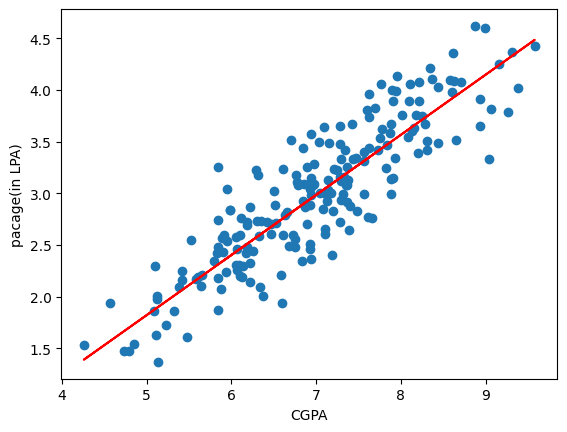

In [73]:
plt.scatter(x = df['cgpa'] , y=df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('pacage(in LPA)')

In [74]:
m=lr.coef_
print(m)

[0.58154877]


In [75]:
b = lr.intercept_
print(b)

-1.0859839580358042


In [76]:
# y = mx + b

### Regression Metrics

In [77]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [78]:
y_pred = lr.predict(X_test)

In [79]:
y_test.values

array([3.09, 4.02, 3.42, 1.37, 3.14, 3.96, 2.79, 3.57, 3.49, 3.52, 3.76,
       2.98, 2.6 , 2.72, 3.76, 2.88, 4.08, 2.87, 2.1 , 3.31, 3.79, 2.35,
       1.86, 2.42, 3.89, 2.55, 4.36, 2.24, 1.94, 2.16, 3.26, 4.08, 3.67,
       3.64, 3.23, 2.84, 2.99, 4.03, 2.94, 2.51])

In [80]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 0.2993118859331679


In [81]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 0.1370062519255721


In [82]:
print("RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE:  0.37014355583418185


In [83]:
print("R2 Score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 Score 0.7283345498058085


In [84]:
# Adjusted R2 score
n = X_test.shape[0]
k = X_test.shape[1]
print(n,k)

40 1


In [85]:
r2_ad = 1 - (((1-r2)*(n-1))/(n-1-k))

In [86]:
print(r2_ad)

0.7211854590112245


In [87]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)
new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.201225,3.26
1,5.12,0.610863,1.98
2,7.82,0.272963,3.25
3,7.42,0.500331,3.67
4,6.94,0.243795,3.57


Text(0, 0.5, 'package(in lpa)')

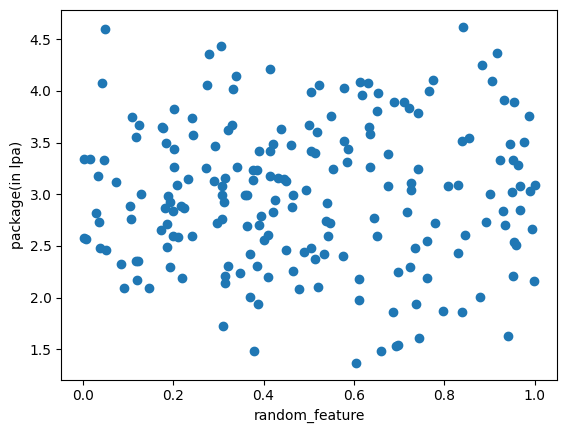

In [88]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('package(in lpa)')

In [89]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=True)
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 0.58,-0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['cgpa','random_feature']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.081
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [90]:
y_pred = lr.predict(X_test)

In [91]:
print("R2 Score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 Score 0.7287011529929734


In [93]:
n = X_test.shape[0]
k = X_test.shape[1]
print(n,k)
r2_ad = 1 - (((1-r2)*(n-1))/(n-1-k))
print(r2_ad)

40 2
0.714036350452053


In [94]:
new_df1 = df.copy()
new_df1['iq'] = new_df1['package'] + np.random.randint(-12,12,200)/10
new_df1 = new_df1[['cgpa','iq','package']]
new_df1.head()

,cgpa,iq,package
0,6.89,3.86,3.26
1,5.12,1.48,1.98
2,7.82,3.05,3.25
3,7.42,3.07,3.67
4,6.94,2.77,3.57


Text(0, 0.5, 'package(in lpa)')

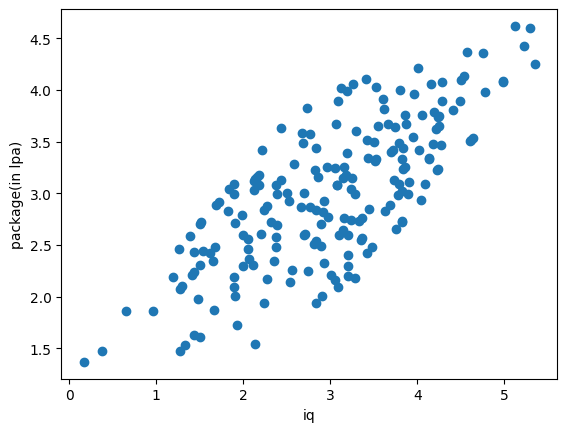

In [95]:
plt.scatter(new_df1['iq'],new_df1['package'])
plt.xlabel('iq')
plt.ylabel('package(in lpa)')

In [96]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=True)
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.47,0.18]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['cgpa','iq']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.8276
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [97]:
y_pred = lr.predict(X_test)
print("R2 Score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 Score 0.8174041201486077


In [98]:
n = X_test.shape[0]
k = X_test.shape[1]
print(n,k)
r2_ad = 1 - (((1-r2)*(n-1))/(n-1-k))
print(r2_ad)

40 2
0.8075340725890731
